In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit
from qiskit.circuit.library import z_feature_map, zz_feature_map, unitary_overlap
from qiskit.primitives import StatevectorSampler

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import shutil
def setup_latex_environment():
    tex_bin = "/sw/rl9c/texlive/2022/rl9_binary/install-tl-20221109/bin/x86_64-linux"
    if shutil.which("latex") or os.path.exists(tex_bin):
        os.environ["PATH"] = tex_bin + ":" + os.environ["PATH"]
        os.environ["TEXMFVAR"] = os.path.expanduser("~/.cache/texmf")
        print("LaTeX environment configured")
        print("latex:", shutil.which("latex"))
        print("dvipng:", shutil.which("dvipng"))
        print("gs:", shutil.which("gs"))
    else:
        print("LaTeX not found")
from tueplots import bundles
plt.style.use(bundles.icml2022())
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 14,
    "lines.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
%matplotlib inline
setup_latex_environment()

LaTeX environment configured
latex: /sw/rl9c/texlive/2022/rl9_binary/install-tl-20221109/bin/x86_64-linux/latex
dvipng: /sw/rl9c/texlive/2022/rl9_binary/install-tl-20221109/bin/x86_64-linux/dvipng
gs: /usr/bin/gs


Circuit depth: 9


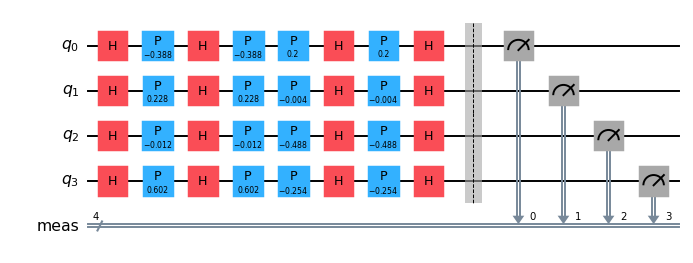

In [53]:
# ------------------------------------------------------------
# Two small mock data points
# ------------------------------------------------------------
x1 = np.array([-0.194, 0.114, -0.006, 0.301])
x2 = np.array([-0.100, 0.002,  0.244, 0.127])

num_features = len(x1)

# Simple feature map
fm = z_feature_map(feature_dimension=num_features)
fm.draw("mpl", scale=0.7)

# Bind classical data to the feature map
U_x1 = fm.assign_parameters(x1)
U_x2 = fm.assign_parameters(x2)

# Build U^\dagger(x2) U(x1)
overlap_circ = unitary_overlap(U_x1, U_x2)
overlap_circ.measure_all()

print("Circuit depth:", overlap_circ.decompose().depth())
overlap_circ.draw("mpl", scale=0.7, filename="overlap_circuit.pdf")

In [49]:
num_shots = 10_000
sampler = StatevectorSampler()

result = sampler.run([overlap_circ], shots=num_shots).result()
counts = result[0].data.meas.get_int_counts()

# Integer 0 corresponds to bitstring 00...0
kernel_entry = counts.get(0, 0) / num_shots

print(f"K(x1, x2) = {kernel_entry:.4f}")

K(x1, x2) = 0.8837


In [22]:
def quantum_kernel_entry(x1, x2, feature_map, shots=10_000):
    """
    Estimate K(x1, x2) = |<psi(x2)|psi(x1)>|^2
    using the compute-uncompute / unitary-overlap circuit.
    """
    U_x1 = feature_map.assign_parameters(x1)
    U_x2 = feature_map.assign_parameters(x2)

    overlap_circ = unitary_overlap(U_x1, U_x2)
    overlap_circ.measure_all()

    sampler = StatevectorSampler()
    result = sampler.run([overlap_circ], shots=shots).result()
    counts = result[0].data.meas.get_int_counts()

    return counts.get(0, 0) / shots

k12 = quantum_kernel_entry(x1, x2, fm, shots=10_000)
print(k12)

0.8834


In [23]:
def quantum_kernel_matrix(X1, X2, feature_map, shots=10_000, symmetric=False):
    """
    Compute a quantum kernel matrix.

    If symmetric=True, assumes X1 == X2 and uses symmetry to save work.
    """
    n1 = len(X1)
    n2 = len(X2)

    K = np.zeros((n1, n2))

    sampler = StatevectorSampler()

    if symmetric:
        for i in range(n1):
            K[i, i] = 1.0

            for j in range(i + 1, n2):
                U_i = feature_map.assign_parameters(X1[i])
                U_j = feature_map.assign_parameters(X2[j])

                overlap_circ = unitary_overlap(U_i, U_j)
                overlap_circ.measure_all()

                result = sampler.run([overlap_circ], shots=shots).result()
                counts = result[0].data.meas.get_int_counts()

                kij = counts.get(0, 0) / shots

                K[i, j] = kij
                K[j, i] = kij

    else:
        for i in range(n1):
            for j in range(n2):
                U_i = feature_map.assign_parameters(X1[i])
                U_j = feature_map.assign_parameters(X2[j])

                overlap_circ = unitary_overlap(U_i, U_j)
                overlap_circ.measure_all()

                result = sampler.run([overlap_circ], shots=shots).result()
                counts = result[0].data.meas.get_int_counts()

                K[i, j] = counts.get(0, 0) / shots

    return K

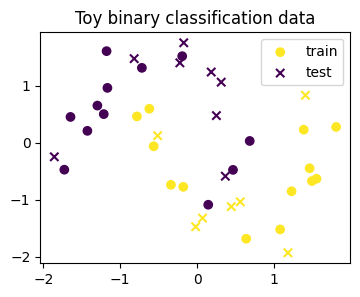

In [24]:
from sklearn.datasets import make_moons

# ------------------------------------------------------------
# Generate small binary dataset
# ------------------------------------------------------------
X, y = make_moons(n_samples=40, noise=0.15, random_state=0)

# Convert labels from {0, 1} to {-1, +1}, optional
y = 2 * y - 1

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=25,
    test_size=15,
    random_state=0,
    stratify=y,
)

plt.figure(figsize=(4, 3))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker="o", label="train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker="x", label="test")
plt.legend()
plt.title("Toy binary classification data")
plt.show()

In [71]:
num_features = X_train.shape[1]

fm = z_feature_map(feature_dimension=num_features)

print(fm)
print("Feature map depth:", fm.decompose().depth())

   ┌───┐┌───────────┐┌───┐┌───────────┐
0: ┤ H ├┤ P(2*x[0]) ├┤ H ├┤ P(2*x[0]) ├
   ├───┤├───────────┤├───┤├───────────┤
1: ┤ H ├┤ P(2*x[1]) ├┤ H ├┤ P(2*x[1]) ├
   └───┘└───────────┘└───┘└───────────┘
Feature map depth: 4


In [72]:
shots = 10_000

K_train = quantum_kernel_matrix(
    X_train,
    X_train,
    feature_map=fm,
    shots=shots,
    symmetric=True,
)

K_test = quantum_kernel_matrix(
    X_test,
    X_train,
    feature_map=fm,
    shots=shots,
    symmetric=False,
)

print("K_train shape:", K_train.shape)
print("K_test shape:", K_test.shape)

K_train shape: (25, 25)
K_test shape: (15, 25)


In [73]:
svc = SVC(kernel="precomputed", C=1.0)
svc.fit(K_train, y_train)

y_pred = svc.predict(K_test)

acc = accuracy_score(y_test, y_pred)

print(f"Quantum kernel SVC accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred))

Quantum kernel SVC accuracy: 0.667
              precision    recall  f1-score   support

          -1       0.64      0.88      0.74         8
           1       0.75      0.43      0.55         7

    accuracy                           0.67        15
   macro avg       0.69      0.65      0.64        15
weighted avg       0.69      0.67      0.65        15



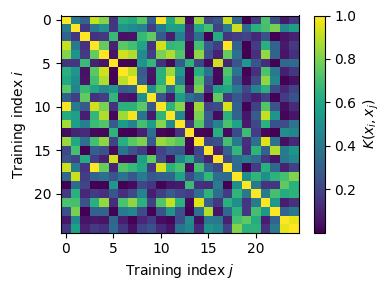

In [74]:
plt.figure(figsize=(4, 3))
plt.imshow(K_train, aspect="auto")
plt.colorbar(label=r"$K(x_i, x_j)$")
plt.title("")
plt.xlabel("Training index $j$")
plt.ylabel("Training index $i$")
plt.tight_layout()
plt.show()

In [75]:
fm_z = z_feature_map(feature_dimension=num_features)

fm_zz = zz_feature_map(
    feature_dimension=num_features,
    reps=1,
    entanglement="linear",
)

for name, fm in [("ZFeatureMap", fm_z), ("ZZFeatureMap", fm_zz)]:
    U1 = fm.assign_parameters(X_train[0])
    U2 = fm.assign_parameters(X_train[1])

    overlap = unitary_overlap(U1, U2)
    overlap.measure_all()

    depth = overlap.decompose(reps=2).depth()
    two_qubit_depth = overlap.decompose().depth(
        lambda instr: len(instr.qubits) > 1
    )

    print(f"{name}")
    print("  overlap depth:", depth)
    print("  two-qubit depth:", two_qubit_depth)

ZFeatureMap
  overlap depth: 9
  two-qubit depth: 1
ZZFeatureMap
  overlap depth: 11
  two-qubit depth: 5


Computing ZFeatureMap kernel...


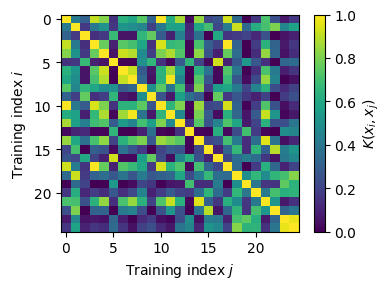

Computing ZZFeatureMap kernel...


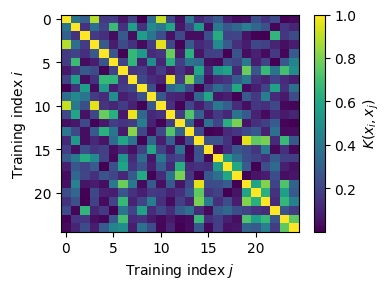

{'ZFeatureMap': 0.6666666666666666, 'ZZFeatureMap': 0.6}


In [76]:
results = {}

for name, fm in [("ZFeatureMap", fm_z), ("ZZFeatureMap", fm_zz)]:
    print(f"Computing {name} kernel...")

    K_train = quantum_kernel_matrix(
        X_train, X_train,
        feature_map=fm,
        shots=shots,
        symmetric=True,
    )

    K_test = quantum_kernel_matrix(
        X_test, X_train,
        feature_map=fm,
        shots=shots,
        symmetric=False,
    )

    plt.figure(figsize=(4, 3))
    plt.imshow(K_train, aspect="auto")
    plt.colorbar(label=r"$K(x_i, x_j)$")
    plt.title("")
    plt.xlabel("Training index $j$")
    plt.ylabel("Training index $i$")
    plt.tight_layout()
    plt.show()

    svc = SVC(kernel="precomputed", C=1.0)
    svc.fit(K_train, y_train)

    y_pred = svc.predict(K_test)
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

print(results)

### More systematic experiment

In [2]:
import time
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score

from qiskit.circuit.library import z_feature_map, zz_feature_map
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

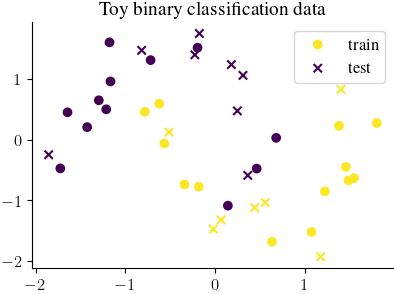

In [3]:
from sklearn.datasets import make_moons

# ------------------------------------------------------------
# Generate small binary dataset
# ------------------------------------------------------------
X, y = make_moons(n_samples=40, noise=0.15, random_state=0)

# Convert labels from {0, 1} to {-1, +1}, optional
y = 2 * y - 1

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=25,
    test_size=15,
    random_state=0,
    stratify=y,
)

plt.figure(figsize=(4, 3))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker="o", label="train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker="x", label="test")
plt.legend()
plt.title("Toy binary classification data")
plt.show()

In [9]:
# X_train, X_test, y_train, y_test
num_features = X_train.shape[1]
reps_values = [1, 2, 4, 8]
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
seed_values = [0, 1, 2]
feature_map_names = ["z", "zz"]
results = []
n_samples = 40
train_size = 25
test_size = 15
noise = 0.15
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)

In [10]:
for seed in seed_values:

    print("\n" + "#" * 80)
    print(f"Seed = {seed}")
    print("#" * 80)

    # ------------------------------------------------------------
    # Generate two-moons data for this seed
    # ------------------------------------------------------------
    X, y = make_moons(
        n_samples=n_samples,
        noise=noise,
        random_state=seed,
    )

    # Optional: labels in {-1, +1}
    y = 2 * y - 1

    # Scale features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Train/test split for this seed
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=train_size,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )

    num_features = X_train.shape[1]

    for feature_map_name in feature_map_names:
        for reps in reps_values:

            print("=" * 70)
            print(f"Seed={seed} | Feature map: {feature_map_name}, reps={reps}")

            # ------------------------------------------------------------
            # Define feature map
            # ------------------------------------------------------------
            if feature_map_name == "z":
                fm = z_feature_map(
                    feature_dimension=num_features,
                    reps=reps,
                )

            elif feature_map_name == "zz":
                fm = zz_feature_map(
                    feature_dimension=num_features,
                    reps=reps,
                    entanglement="linear",
                )

            else:
                raise ValueError(f"Unknown feature map: {feature_map_name}")

            circuit_depth = fm.decompose().depth()
            num_qubits = fm.num_qubits

            print(f"Number of qubits: {num_qubits}")
            print(f"Circuit depth:    {circuit_depth}")

            # ------------------------------------------------------------
            # Build quantum kernel
            # ------------------------------------------------------------
            quantum_kernel = FidelityQuantumKernel(
                feature_map=fm,
                fidelity=fidelity,
                enforce_psd=True,
            )

            # ------------------------------------------------------------
            # Compute Gram matrices once per seed / feature map / reps
            # ------------------------------------------------------------
            t0 = time.time()

            K_train = quantum_kernel.evaluate(x_vec=X_train)
            K_test = quantum_kernel.evaluate(x_vec=X_test, y_vec=X_train)

            kernel_time_sec = time.time() - t0

            print(f"Kernel computation time: {kernel_time_sec:.2f} sec")

            # ------------------------------------------------------------
            # Kernel diagnostics
            # ------------------------------------------------------------
            off_diag = K_train[~np.eye(K_train.shape[0], dtype=bool)]

            eigvals = np.linalg.eigvalsh(K_train)
            eig_min = eigvals.min()
            eig_max = eigvals.max()
            condition_number = eig_max / max(eig_min, 1e-12)

            mean_diag = np.mean(np.diag(K_train))
            mean_offdiag = np.mean(off_diag)
            std_offdiag = np.std(off_diag)

            # ------------------------------------------------------------
            # Train SVMs with different values of C
            # ------------------------------------------------------------
            for C in C_values:

                print(f"Training SVM with C={C}")

                t1 = time.time()

                clf = SVC(
                    kernel="precomputed",
                    C=C,
                )

                clf.fit(K_train, y_train)

                train_time_sec = time.time() - t1

                y_train_pred = clf.predict(K_train)
                y_test_pred = clf.predict(K_test)

                train_acc = accuracy_score(y_train, y_train_pred)
                test_acc = accuracy_score(y_test, y_test_pred)

                train_bal_acc = balanced_accuracy_score(y_train, y_train_pred)
                test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)

                results.append({
                    "seed": seed,
                    "feature_map": feature_map_name,
                    "reps": reps,
                    "C": C,
                    "num_features": num_features,
                    "num_qubits": num_qubits,
                    "circuit_depth": circuit_depth,
                    "kernel_time_sec": kernel_time_sec,
                    "train_time_sec": train_time_sec,
                    "train_accuracy": train_acc,
                    "test_accuracy": test_acc,
                    "train_balanced_accuracy": train_bal_acc,
                    "test_balanced_accuracy": test_bal_acc,
                    "mean_diag": mean_diag,
                    "mean_offdiag": mean_offdiag,
                    "std_offdiag": std_offdiag,
                    "eig_min": eig_min,
                    "eig_max": eig_max,
                    "condition_number": condition_number,
                    "n_train": len(X_train),
                    "n_test": len(X_test),
                })

results_df = pd.DataFrame(results)
results_df


################################################################################
Seed = 0
################################################################################
Seed=0 | Feature map: z, reps=1
Number of qubits: 2
Circuit depth:    2
Kernel computation time: 2.56 sec
Training SVM with C=0.01
Training SVM with C=0.1
Training SVM with C=1.0
Training SVM with C=10.0
Training SVM with C=100.0
Seed=0 | Feature map: z, reps=2
Number of qubits: 2
Circuit depth:    4
Kernel computation time: 3.21 sec
Training SVM with C=0.01
Training SVM with C=0.1
Training SVM with C=1.0
Training SVM with C=10.0
Training SVM with C=100.0
Seed=0 | Feature map: z, reps=4
Number of qubits: 2
Circuit depth:    8
Kernel computation time: 3.61 sec
Training SVM with C=0.01
Training SVM with C=0.1
Training SVM with C=1.0
Training SVM with C=10.0
Training SVM with C=100.0
Seed=0 | Feature map: z, reps=8
Number of qubits: 2
Circuit depth:    16
Kernel computation time: 5.06 sec
Training SVM with C=0.01
Traini

,seed,feature_map,reps,C,num_features,num_qubits,circuit_depth,kernel_time_sec,train_time_sec,train_accuracy,...,train_balanced_accuracy,test_balanced_accuracy,mean_diag,mean_offdiag,std_offdiag,eig_min,eig_max,condition_number,n_train,n_test
0,0,z,1,0.01,2,2,2,2.557497,0.009295,0.52,...,0.500000,0.500000,1.012964,0.265104,0.288711,-4.089647e-16,8.186086,8.186086e+12,25,15
1,0,z,1,0.10,2,2,2,2.557497,0.000684,0.52,...,0.500000,0.500000,1.012964,0.265104,0.288711,-4.089647e-16,8.186086,8.186086e+12,25,15
2,0,z,1,1.00,2,2,2,2.557497,0.000629,0.84,...,0.839744,0.669643,1.012964,0.265104,0.288711,-4.089647e-16,8.186086,8.186086e+12,25,15
3,0,z,1,10.00,2,2,2,2.557497,0.000629,0.92,...,0.919872,0.455357,1.012964,0.265104,0.288711,-4.089647e-16,8.186086,8.186086e+12,25,15
4,0,z,1,100.00,2,2,2,2.557497,0.000706,1.00,...,1.000000,0.812500,1.012964,0.265104,0.288711,-4.089647e-16,8.186086,8.186086e+12,25,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2,zz,8,0.01,2,2,40,8.049654,0.000925,0.52,...,0.500000,0.500000,1.008583,0.339626,0.233235,-5.596177e-16,9.815539,9.815539e+12,25,15
116,2,zz,8,0.10,2,2,40,8.049654,0.000608,0.52,...,0.500000,0.500000,1.008583,0.339626,0.233235,-5.596177e-16,9.815539,9.815539e+12,25,15
117,2,zz,8,1.00,2,2,40,8.049654,0.000597,0.84,...,0.846154,0.535714,1.008583,0.339626,0.233235,-5.596177e-16,9.815539,9.815539e+12,25,15
118,2,zz,8,10.00,2,2,40,8.049654,0.000615,0.92,...,0.919872,0.464286,1.008583,0.339626,0.233235,-5.596177e-16,9.815539,9.815539e+12,25,15


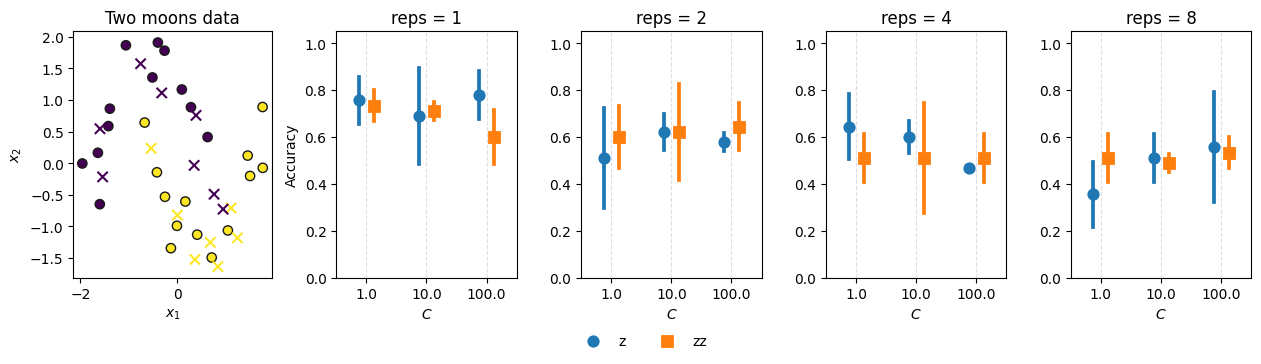

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
results_df = results_df[results_df["C"] >= 1.0]
metric = "test_accuracy"   # or "test_balanced_accuracy"
reps_values = sorted(results_df["reps"].unique())
n_reps = len(reps_values)

#sns.set_theme(style="whitegrid", context="paper")
sns.reset_defaults()

# ------------------------------------------------------------
# Figure layout:
# 1 column for data + one column per reps value
# ------------------------------------------------------------
fig = plt.figure(figsize=(3.2 + 3.0 * n_reps, 3.2))

gs = fig.add_gridspec(
    nrows=1,
    ncols=n_reps + 1,
    width_ratios=[1.1] + [1.0] * n_reps,
    wspace=0.35,
)

# ------------------------------------------------------------
# Left panel: two moons data
# ------------------------------------------------------------
ax_data = fig.add_subplot(gs[0, 0])

ax_data.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    marker="o",
    edgecolor="k",
    s=45,
    label="train",
)

ax_data.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    marker="x",
    s=55,
    label="test",
)

ax_data.set_title("Two moons data")
ax_data.set_xlabel(r"$x_1$")
ax_data.set_ylabel(r"$x_2$")

# ------------------------------------------------------------
# Right panels: one pointplot per reps value
# ------------------------------------------------------------
axes = []

for idx, reps in enumerate(reps_values):
    ax = fig.add_subplot(gs[0, idx + 1])
    axes.append(ax)

    df_rep = results_df[results_df["reps"] == reps].copy()

    sns.pointplot(
        data=df_rep,
        x="C",
        y=metric,
        hue="feature_map",
        dodge=0.25,
        markers=["o", "s"],
        linestyles="none",
        errorbar="sd",
        ax=ax,
    )

    for xpos in ax.get_xticks():
        ax.axvline(
            x=xpos,
            color="gray",
            linestyle="--",
            linewidth=0.8,
            alpha=0.25,
            zorder=0,
        )

    ax.set_title(f"reps = {reps}")
    ax.set_xlabel(r"$C$")
    
    if idx == 0:
        ax.set_ylabel("Accuracy")
    else:
        ax.set_ylabel("")

    ax.set_ylim(0.0, 1.05)
    ax.grid(False)

    # Remove duplicated legends from individual axes
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# ------------------------------------------------------------
# Common legend
# ------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False,
)

#fig.suptitle("Quantum-kernel SVM accuracy across feature maps, reps, and C", y=1.05)
plt.savefig("quantum_kernel_svm_accuracy.pdf", bbox_inches="tight", dpi=300)
plt.tight_layout
plt.show()

In [24]:
fm = zz_feature_map(
                    feature_dimension=num_features,
                    reps=1,
                    entanglement="circular",
                )
fm.draw()

┌───┐┌───────────┐                                          
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘